# argentina.ciudades — Demografía argentina

Recorrido **usando el paquete** sobre los datos demográficos del Censo Nacional 2022 (INDEC):

1. Top de ciudades y provincias por población.
2. Concentración urbana por provincia.
3. Mapa de las 30 principales ciudades sobre Argenmap IGN.

## 1. Setup

In [1]:
import argentina as arg
import pandas as pd
import matplotlib.pyplot as plt

print(f"argentina v{arg.__version__}")
print(f"ciudades en set: {len(arg.ciudades)}")
print(f"provincias:      {len(arg.provincias)}")

argentina v0.0.23
ciudades en set: 33
provincias:      24


## 2. Ranking de provincias por población (Censo 2022)

In [2]:
df_prov = pd.DataFrame([
    {'provincia': p.nombre, 'region': p.region, 'poblacion': p.poblacion_2022}
    for p in arg.provincias
]).sort_values('poblacion', ascending=False).reset_index(drop=True)

df_prov['share_%'] = (df_prov['poblacion'] / df_prov['poblacion'].sum() * 100).round(2)
df_prov['cumulado_%'] = df_prov['share_%'].cumsum().round(2)
df_prov

,provincia,region,poblacion,share_%,cumulado_%
0,Buenos Aires,Pampeana,17569053,38.28,38.28
1,Córdoba,Pampeana,3840905,8.37,46.65
2,Santa Fe,Pampeana,3556522,7.75,54.40
3,Ciudad Autónoma de Buenos Aires,CABA,3121707,6.80,61.20
4,Mendoza,Cuyo,2014533,4.39,65.59
5,Tucumán,NOA,1694656,3.69,69.28
6,Entre Ríos,Pampeana,1426426,3.11,72.39
7,Salta,NOA,1424397,3.10,75.49
8,Misiones,NEA,1280960,2.79,78.28
9,Corrientes,NEA,1212696,2.64,80.92


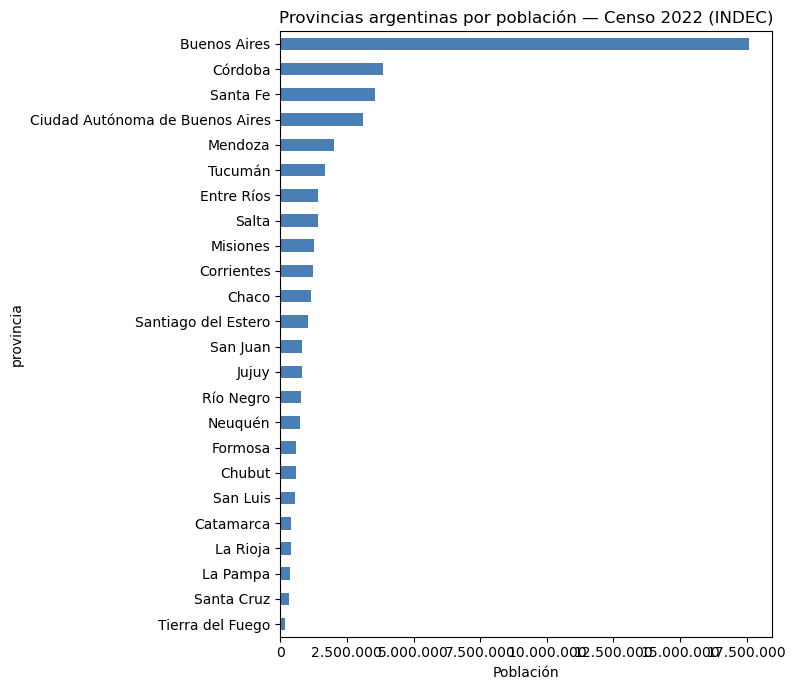

In [3]:
fig, ax = plt.subplots(figsize=(8, 7))
df_prov.set_index('provincia')['poblacion'].sort_values().plot.barh(ax=ax, color='#4a7fb5')
ax.set_xlabel('Población')
ax.set_title('Provincias argentinas por población — Censo 2022 (INDEC)')
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
plt.tight_layout()
plt.show()

## 3. Concentración: Buenos Aires + CABA

¿Qué porcentaje del país vive en el AMBA?

In [4]:
ba = arg.provincias.BUENOS_AIRES.poblacion_2022
caba = arg.provincias.CABA.poblacion_2022
total = sum(p.poblacion_2022 for p in arg.provincias)

print(f'CABA + Buenos Aires: {ba + caba:>11,}'.replace(',', '.'))
print(f'Total país:          {total:>11,}'.replace(',', '.'))
print(f'Share AMBA:          {(ba + caba) / total:>10.1%}')

CABA + Buenos Aires:  20.690.760
Total país:           45.892.863
Share AMBA:               45.1%


## 4. Top 10 ciudades por población

In [5]:
df_ciud = pd.DataFrame([
    {'ciudad': c.nombre, 'provincia': c.provincia_nombre, 'poblacion': c.poblacion_2022, 'lat': c.lat, 'lon': c.lon}
    for c in arg.ciudades
]).sort_values('poblacion', ascending=False).reset_index(drop=True)

df_ciud.head(10)

,ciudad,provincia,poblacion,lat,lon
0,Buenos Aires,Ciudad Autónoma de Buenos Aires,3121707,-34.6037,-58.3816
1,Córdoba,Córdoba,1565112,-31.4201,-64.1888
2,Rosario,Santa Fe,1028658,-32.9442,-60.6505
3,La Plata,Buenos Aires,772618,-34.9214,-57.9544
4,San Miguel de Tucumán,Tucumán,695807,-26.8083,-65.2176
5,Mar del Plata,Buenos Aires,682605,-38.0023,-57.5575
6,Salta,Salta,618375,-24.7821,-65.4232
7,San Juan,San Juan,471389,-31.5375,-68.5364
8,Santa Fe,Santa Fe,415345,-31.6107,-60.6973
9,Resistencia,Chaco,387341,-27.4517,-58.9867


## 5. Población agrupada por región

In [6]:
por_region = df_prov.groupby('region')['poblacion'].sum().sort_values(ascending=False)
por_region

region
Pampeana     26758928
NOA           5780005
NEA           4242660
Cuyo          3373672
CABA          3121707
Patagonia     2615891
Name: poblacion, dtype: int64

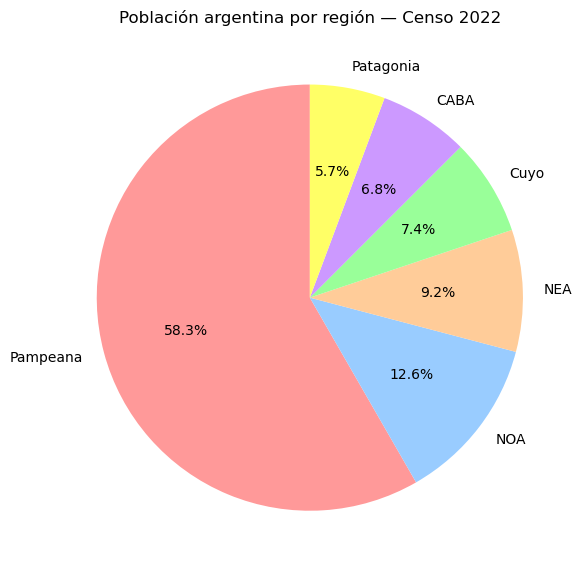

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    por_region.values,
    labels=por_region.index,
    autopct=lambda p: f'{p:.1f}%',
    colors=['#ff9999', '#99ccff', '#ffcc99', '#99ff99', '#cc99ff', '#ffff66'],
    startangle=90,
)
ax.set_title('Población argentina por región — Censo 2022')
plt.tight_layout()
plt.show()

## 6. Mapa: ciudades principales sobre Argenmap

Tamaño del círculo proporcional a la población. Fondo IGN para preservar toponimia argentina.

In [8]:
import folium
from argentina.geo import basemaps

m = folium.Map(location=[-38, -64], zoom_start=4, tiles=None)
basemaps.add_argenmap(m)

# Escala: radio en píxeles proporcional a sqrt(poblacion) para que se vea bien
max_pop = max(c.poblacion_2022 for c in arg.ciudades if c.poblacion_2022)

for c in arg.ciudades:
    if c.poblacion_2022 is None or c.lat is None:
        continue
    radio = 4 + 22 * (c.poblacion_2022 / max_pop) ** 0.5
    popup = (
        f"<b>{c.nombre}</b><br>"
        f"{c.provincia_nombre}<br>"
        f"Población (2022): <b>{c.poblacion_2022:,}</b>".replace(',', '.')
    )
    folium.CircleMarker(
        location=[c.lat, c.lon],
        radius=radio,
        color='black',
        weight=0.5,
        fill=True,
        fill_color='#cc3333',
        fill_opacity=0.55,
        popup=folium.Popup(popup, max_width=240),
        tooltip=f"{c.nombre} — {c.poblacion_2022:,}".replace(',', '.'),
    ).add_to(m)

basemaps.add_creditos_argentina(m)
basemaps.add_layer_control(m)
m

## Notas

- Fuente: **Censo Nacional de Población, Hogares y Viviendas 2022 (INDEC)**.
- Las poblaciones de `Ciudad.poblacion_2022` corresponden a municipio/partido/comuna, no al aglomerado urbano completo. Por eso "Mendoza" aparece chica (115k) — el Gran Mendoza tiene >1M pero distribuido en varios departamentos.
- `Provincia.poblacion_2022` es la población total provincial.
- Para cualquier ciudad que no esté en el set curado, usá `argentina.geo.direcciones.coordenadas(...)` o el shape del IGN para georreferenciar.